In [1]:
import numpy as np
from pyscf import gto, scf, cc
import jax
jax.config.update("jax_enable_x64", True)

####  test H2 monomers ####
a = 2. # bond length in a cluster
d = 10 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
elmt = 'C'
unit = 'B'
basis = 'sto6g'
atoms = ''
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis=basis,
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

stable = False
for i in range(10):
    print(f'mf stability test {i+1}')
    if not stable:
        mo_i, _, stable,_ = mf.stability(return_status=True)
        dm = mf.make_rdm1(mo_i,mf.mo_occ)
        mf.kernel(dm0=dm)
    elif stable:
        print(f'mf energy: {mf.e_tot}, stability {stable}')
        break

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

et = mycc.ccsd_t()
print(f"CCSD(T) Energy = {mycc.e_tot + et}")

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sun Aug  9 15:19:48 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 12
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit

In [2]:
from afqmc import prep_exp
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-6)


Preparing AFQMC calculation
CCSD type input object
Calculating Cholesky integrals
Cholesky shape: (49, 8, 8) 
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [4, 4]
Number of basis functions:  8
Number of Cholesky vectors: 49


In [5]:
import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 18,
            'guide': 'rhf',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 10,
            }

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)
ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [6]:
print(sampler)
print(prop)

sampler(n_walkers=300, n_prop_steps=50, n_blocks=100, n_chol=49)
propagator_restricted(dt=0.005, n_walkers=300, n_exp_terms=6, n_batch=1)


In [7]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples, np.complex128)
en_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean.real:10.5f}  {energy_mean.real:12.5f}  {energy_err.real:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j        3.37
 5.00   300.50993     -75.28658       nan        6.98
10.00   299.26611     -75.25165       nan        7.36
15.00   299.06035     -75.27877       nan        7.75
20.00   299.82229     -75.30301       nan        8.13
25.00   299.10359     -75.23732       nan        8.51
30.00   299.67953     -75.27513       nan        8.90
35.00   299.72308     -75.26133       nan        9.28
40.00   299.15416     -75.24095       nan        9.66
45.00   300.43829     -75.36386       nan       10.05
50.00   299.71923     -75.24923       nan       10.43
55.00   299.31279     -75.30997       nan       10.81
60.00   299.43046     -75.30077       nan       11.20
65.00   299.26512     -75.30374       nan       11.58
70.00   299.39566     -75.26099       nan       11.97
75.00   299.28879     -75.26472       nan       12.35
80.00   299.11694     -75.26883       nan       12.74
85.00  

E = -75.285100 +/- 0.002074 Ha  (averaged over 421 blocks, t >= 20)


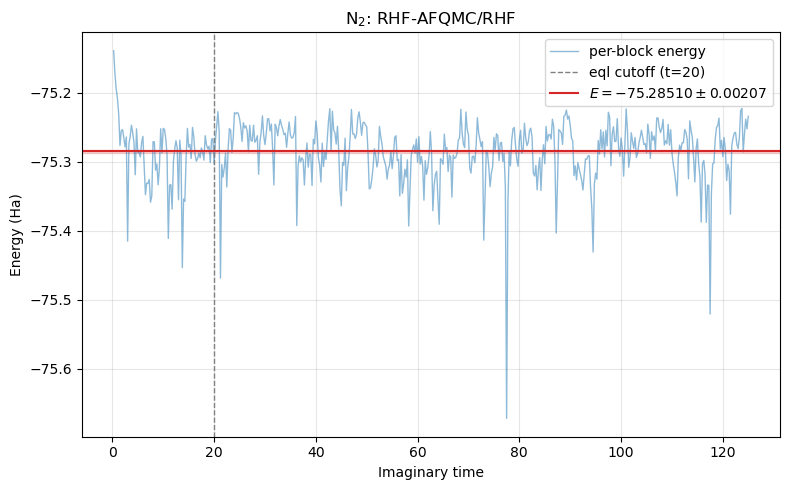

In [8]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: RHF-AFQMC/RHF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rcisd',
            'trial': 'rhf',
            }

import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [8]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples, np.complex128)
en_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean.real:10.5f}  {energy_mean.real:12.5f}  {energy_err.real:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j        2.33
 5.00   227.08168     -75.30146       nan        6.85
10.00   227.30392     -75.29651       nan        7.48
15.00   226.21414     -75.29304       nan        8.11
20.00   231.66381     -75.28689       nan        8.73
25.00   228.05988     -75.29875       nan        9.37
30.00   225.45521     -75.31594       nan       10.00
35.00   228.19519     -75.28227       nan       10.62
40.00   232.37039     -75.25792       nan       11.25
45.00   218.39736     -75.32984       nan       11.88
50.00   226.36497     -75.31173       nan       12.52
55.00   226.53502     -75.28094       nan       13.14
60.00   225.64596     -75.28811       nan       13.77
65.00   218.32889     -75.32247       nan       14.40
70.00   227.80916     -75.27968       nan       15.03
75.00   224.50002     -75.32263       nan       15.66
80.00   232.00043     -75.27845       nan       16.30
85.00  

E = -75.295846 +/- 0.001048 Ha  (averaged over 421 blocks, t >= 20)


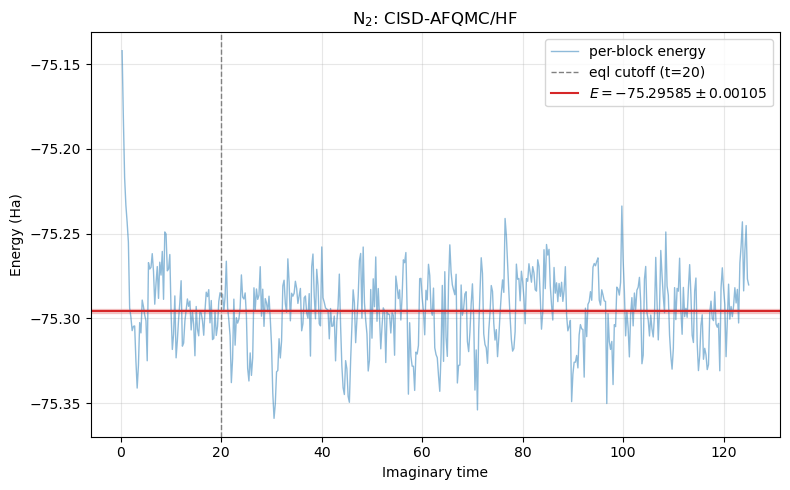

In [9]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 10,
            }

import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [11]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples, np.complex128)
en_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean.real:10.5f}  {energy_mean.real:12.5f}  {energy_err.real:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j        6.63
 5.00   228.20974     -75.32429       nan       12.92
10.00   230.47768     -75.24585       nan       15.89
15.00   224.56759     -75.31433       nan       18.86
20.00   222.65025     -75.27696       nan       21.82
25.00   213.83530     -75.30723       nan       24.79
30.00   232.04475     -75.28149       nan       27.76
35.00   234.23478     -75.28359       nan       30.73
40.00   224.85714     -75.32788       nan       33.70
45.00   225.13222     -75.28096       nan       36.67
50.00   224.02715     -75.30753       nan       39.63
55.00   230.87607     -75.29871       nan       42.60
60.00   226.05955     -75.29102       nan       45.57
65.00   234.04438     -75.25356       nan       48.54
70.00   225.70728     -75.32787       nan       51.51
75.00   226.10838     -75.29489       nan       54.48
80.00   227.00857     -75.26191       nan       57.45
85.00  

E = -75.292252 +/- 0.001315 Ha  (averaged over 421 blocks, t >= 20)


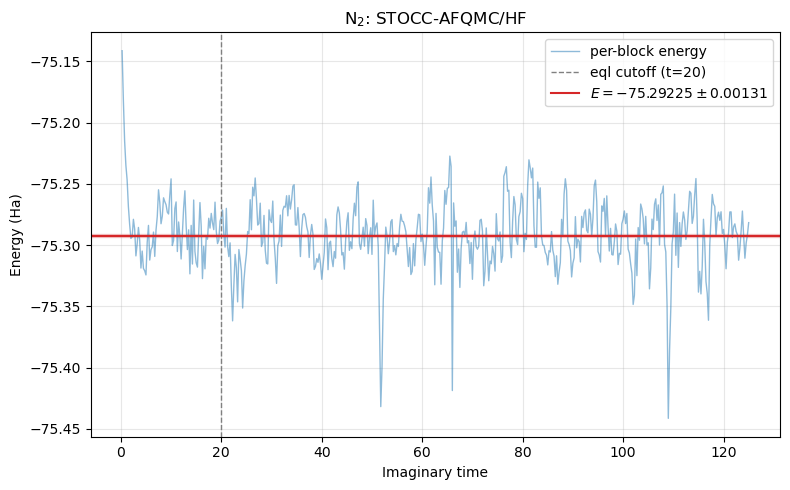

In [12]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: STOCC-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rcisd',
            'trial': 'rcisd',
            }

import time
import numpy as np
from afqmc import config

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [14]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples)
en_sp = np.zeros(nsamples)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean.real
    en_sp[n] = energy_mean.real

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean:10.5f}  {energy_mean:12.5f}  {energy_err:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.32137+0.00000j        2.84
 5.00  299.62339-0.00000j  -75.33577-0.00075j       nan        7.67
10.00  299.50355-0.00000j  -75.32144+0.00126j       nan        8.40
15.00  299.47960-0.00000j  -75.33030-0.00177j       nan        9.13
20.00  299.49822-0.00000j  -75.32871-0.00142j       nan        9.86
25.00  299.07163+0.00000j  -75.32073-0.00429j       nan       10.59
30.00  299.64853+0.00000j  -75.32346+0.00203j       nan       11.32
35.00  299.34585-0.00000j  -75.32567+0.00291j       nan       12.05
40.00  299.42861-0.00000j  -75.33629+0.00037j       nan       12.78
45.00  299.39270+0.00000j  -75.32592+0.00429j       nan       13.51
50.00  299.39985-0.00000j  -75.32556+0.00920j       nan       14.24
55.00  299.35740-0.00000j  -75.32912+0.00219j       nan       14.97
60.00  299.46473-0.00000j  -75.31800-0.00149j       nan       15.70
65.00  299.45022-0.00000j  -75.31726-0.00493j       nan

E = -75.327773 +/- 0.000371 Ha  (averaged over 421 blocks, t >= 20)


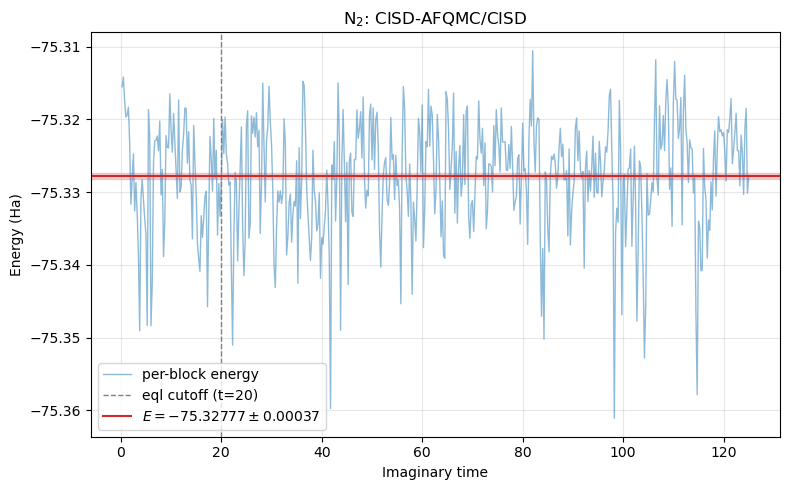

In [16]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: CISD-AFQMC/CISD")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
from jax import jit, lax, random
from afqmc import cc_tools

@partial(jit, static_argnums=(0, 1))
def propagate(
    self,
    trial,
    ham_data: dict,
    prop_data: dict,
    fields: jax.Array,
    wave_data: dict,
) -> dict:
    
    overlaps00 = prop_data["overlaps"] # <G(i)|w(i)>
    # update Guide <G(i)| -> <G(i+1)|
    wave_data["slaters"], prop_data["key"] = cc_tools.get_stoccsd(
        wave_data["mo_t"], wave_data["tau"], self.n_slater, prop_data["key"])
    # <G(i+1)|w(i)>
    overlaps10 = trial.calc_overlap(prop_data["walkers"], wave_data)
    
    force_bias = trial.calc_force_bias(prop_data["walkers"], ham_data, wave_data)
    field_shifts = -jnp.sqrt(self.dt) * (1.0j * force_bias - ham_data["mf_shifts"]) # xbar
    shifted_fields = fields - field_shifts # x-xbar
    shift_term = jnp.sum(shifted_fields * ham_data["mf_shifts"], axis=1) # (x-xbar)*m
    fb_term = jnp.sum(
        fields * field_shifts - field_shifts * field_shifts / 2.0, axis=1
    ) # x*xbar - xbar^2/2

    prop_data["walkers"] = self._apply_trotprop(
        ham_data, prop_data["walkers"], shifted_fields
    ) # exp(-th1/2) exp(sqrt(t)(x-xbar)v) exp(-th1/2) |w>

    # <G(i+1)|w(i+1)>
    overlaps11 = trial.calc_overlap(prop_data["walkers"], wave_data)
    # I(x,xbar,walkers,trial) = <trial|walkers_new>/<trial|walkers_old> 
    #                                 * exp(x_g xbar_g - 1/2 xbar_g xbar_g)

    r10_00 = overlaps10 / overlaps00 # <G(i+1)|w(i)>/<G(i)|w(i)>
    r11_10 = overlaps11 / overlaps10 # <G(i+1)|w(i+1)>/<G(i+1)|w(i)>
    r11_00 = overlaps11 / overlaps00 # <G(i+1)|w(i+1)>/<G(i)|w(i)>

    imp_fun = jnp.exp(-jnp.sqrt(self.dt) * shift_term # from sqrt(t)(x-xbar)(v-m)
                      + fb_term # pop_control_ene_shift = estimated ground state energy
                      + self.dt * (prop_data["pop_control_ene_shift"] + ham_data["h0_prop"])
                      ) * r11_00
    
    theta_g = jnp.angle(r10_00)
    theta_w = jnp.angle(jnp.exp(-jnp.sqrt(self.dt) * shift_term) * r11_10)
    cos_g = jnp.cos(theta_g)
    cos_w = jnp.cos(theta_w)
    cos_g = jnp.where(cos_g < 0, 0.0, cos_g)
    cos_w = jnp.where(cos_w < 0, 0.0, cos_w)

    imp_fun_phaseless = jnp.abs(imp_fun) * cos_w #* jnp.exp(1j*theta_g)
    imp_fun_phaseless = jnp.array(jnp.where(jnp.isnan(imp_fun_phaseless), 0.0, imp_fun_phaseless))
    imp_fun_phaseless = jnp.where(imp_fun_phaseless < 1.0e-3, 0.0, imp_fun_phaseless)
    imp_fun_phaseless = jnp.where(imp_fun_phaseless > 100.0, 0.0, imp_fun_phaseless)

    prop_data["weights"] = imp_fun_phaseless * prop_data["weights"]
    prop_data["weights"] = jnp.array(jnp.where(prop_data["weights"] > 100, 0.0, prop_data["weights"]))
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"] \
        - 0.1 * jnp.array(jnp.log(jnp.sum(prop_data["weights"]) / self.n_walkers) / self.dt)
    prop_data["overlaps"] = overlaps11
    prop_data["cos_w"] = cos_w
    prop_data["cos_g"] = cos_g

    return prop_data, wave_data

In [52]:
from afqmc import sampling_exp

@partial(jit, static_argnums=(0, 1, 2))
def prop_nstep(sampler, prop, wave, prop_data, ham_data, wave_data):
    """Phaseless propagation scan function over steps."""
    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            sampler.n_prop_steps,
            sampler.n_walkers,
            sampler.n_chol,
        ),
    )

    def scan_fn(carry, field):
        prop_data, wave_data = carry
        prop_data, wave_data = propagate(prop, wave, ham_data, prop_data, field, wave_data)
        return (prop_data, wave_data), None

    (prop_data, wave_data), _ = lax.scan(scan_fn, (prop_data, wave_data), fields)

    prop_data["n_killed_walkers"] \
        = prop_data["weights"].size - jnp.count_nonzero(prop_data["weights"])

    prop_data = prop.orthonormalize_walkers(prop_data)

    return prop_data, wave_data


@partial(jit, static_argnums=(0,1,2))
def block_sample(
    sampler,
    prop,
    wave,
    prop_data,
    ham_data,
    wave_data,
    ):
    """Block scan function. Propagation and energy calculation."""
    prop_data, wave_data = prop_nstep(sampler, prop, wave, prop_data, ham_data, wave_data)
    
    guide_olps = wave.calc_overlap(prop_data["walkers"], wave_data)
    guide_enes = wave.calc_guide_energy(prop_data["walkers"], ham_data, wave_data)

    outlier = jnp.abs(guide_enes - prop_data["e_estimate"]) > jnp.sqrt(2.0 / prop.dt) # 20 Ha for dt = 0.005
    prop_data["weights"] = jnp.where(outlier, 0.0, prop_data["weights"])

    trial_olps = wave.calc_trial_overlap(prop_data["walkers"], wave_data)
    trial_enes = wave.calc_energy(prop_data["walkers"], ham_data, wave_data)

    olp_ratio = trial_olps / guide_olps
    weighps = prop_data["weights"] * olp_ratio

    wt, gsp_mean, gsp_err = sampling_exp.weighted_average(prop_data["weights"], guide_enes)
    wp, tsp_mean, tsp_err = sampling_exp.weighted_average(weighps, trial_enes)

    prop_data = prop.stochastic_reconfiguration_local(prop_data)
    prop_data["overlaps"] = wave.calc_overlap(prop_data["walkers"], wave_data)

    return prop_data, (wt, gsp_mean, gsp_err, wp, tsp_mean, tsp_err)

In [53]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 10,
            }

import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
prop_data["cos_g"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
prop_data["cos_w"] = jnp.ones(options["n_walkers"], dtype=jnp.float64)
# prop_data["weights"] = jnp.ones(options["n_walkers"], dtype=jnp.complex128)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [54]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wts_sp = np.zeros(nsamples, np.complex128)
eng_sp = np.zeros(nsamples, np.complex128)
wps_sp = np.zeros(nsamples, np.complex128)
ent_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (wt, gsp_mean, gsp_err, wp, tsp_mean, tsp_err) \
        = block_sample(sampler, prop, wave, prop_data, ham_data, wave_data)

#     weight_mean, energy_mean, energy_err \
#             = wave.energy_formula(weight, sample, ham_data)
    wts_sp[n] = wt
    eng_sp[n] = gsp_mean
    wps_sp[n] = wp
    ent_sp[n] = tsp_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt:10.5f}  {gsp_mean:12.5f}  "
              f"{wp:10.5f}  {tsp_mean:12.5f}  "
              f"{prop_data['cos_g'].mean():12.5f}  {prop_data['cos_w'].mean():12.5f}"
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -75.07744+0.00000j        1.06
 5.00   298.48178  -75.36235-0.00592j  224.87741+2.57787j  -75.28533+0.00968j       0.98979       0.99986      7.89
10.00   291.13614  -75.28276+0.05692j  234.99001+4.94389j  -75.28986+0.01247j       0.97798       0.99987     11.05
15.00   326.22397  -75.20931+0.00016j  229.89178+3.66160j  -75.26288+0.00655j       0.97603       0.99982     14.21
20.00   340.14416  -75.49092-0.11167j  216.07135-0.03017j  -75.30467+0.00724j       0.98460       0.99939     17.37
25.00   314.46546  -75.32916+0.02494j  233.49086-2.01621j  -75.26979+0.00662j       0.98869       0.99981     20.53
30.00   355.30814  -75.35982+0.04862j  197.77905+0.97356j  -75.32364+0.01649j       0.94685       0.99670     23.69
35.00   349.09503  -75.25027+0.00108j  228.59418+3.39593j  -75.30390+0.00711j       0.97905       0.99981     26.86
40.00   279.71100  -75.24646+0.02801j  222.35738+1.16491j  

Eg = -75.324429 +/- 0.001887 Ha  (averaged over 421 blocks, t >= 20)
Et = -75.291503 +/- 0.001107 Ha  (averaged over 421 blocks, t >= 20)


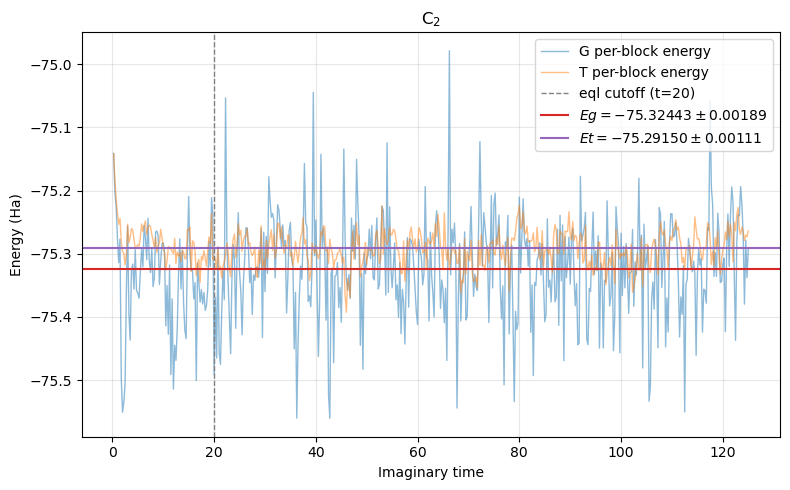

In [55]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
wg = wts_sp[mask]
eg = eng_sp[mask]
wt = wps_sp[mask]
et = ent_sp[mask]
N = len(eg)

# weight-averaged energy
Eg_mean = (np.sum(wg * eg) / np.sum(wg)).real
Et_mean = (np.sum(wt * et) / np.sum(wt)).real

# weighted variance (Bessel-corrected) -> std of the mean
wgvar = np.sum(wg * (eg - Eg_mean) ** 2) / np.sum(wg) * N / (N - 1)
semg = np.sqrt(wgvar / N).real
wtvar = np.sum(wt * (et - Et_mean) ** 2) / np.sum(wt) * N / (N - 1)
semt = np.sqrt(wtvar / N).real

print(f"Eg = {Eg_mean:.6f} +/- {semg:.6f} Ha  (averaged over {N} blocks, t >= 20)")
print(f"Et = {Et_mean:.6f} +/- {semt:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, eng_sp.real, lw=1, alpha=0.5, label="G per-block energy")
plt.plot(imag_time, ent_sp.real, lw=1, alpha=0.5, label="T per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(Eg_mean, color="C3", lw=1.5, label=fr"$Eg = {Eg_mean:.5f} \pm {semg:.5f}$")
plt.axhline(Et_mean, color="C4", lw=1.5, label=fr"$Et = {Et_mean:.5f} \pm {semt:.5f}$")
# plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("C$_2$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()